In [1]:
import os
import random
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import copy
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms
from torchvision.transforms import functional as TF
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import warnings
warnings.filterwarnings('ignore')

import albumentations as A
print("✅ All libraries imported successfully!")

# =============================================================================
# CELL 2: SEED EVERYTHING & GPU CHECK
# =============================================================================

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

if torch.cuda.is_available():
    print(f"🔥 GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"✅ FP16 (Half Precision) Supported: True")
else:
    print("⚠️ No GPU detected. Training will be slow on CPU.")
# ══════════════════════════════════════════════════════════════
# Cell 1: Installs & Imports
# ══════════════════════════════════════════════════════════════


import os, glob, random, math, warnings, time, copy

seed_everything(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR = './saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

✅ All libraries imported successfully!
🖥️  Device: cuda
🔥 GPU Name: Tesla T4
✅ FP16 (Half Precision) Supported: True


🖥️  Device: cuda

╔============================================================╗
║  AUGMENTATION + DATALOADER PIPELINE                      ║
╚============================================================╝

📊 BUILDING DATALOADERS

Total images: 1097
Distribution: {0: 120, 1: 561, 2: 416}
  Benign: 120 images
  Malignant: 561 images
  Normal: 416 images

✂️  Split: Train=767, Val=165, Test=165
Train distribution: {0: 84, 1: 392, 2: 291}

✅ Classes present: ['Benign', 'Malignant', 'Normal']

🎯 Class weights for loss:
  Benign: 3.04× penalty
  Malignant: 0.65× penalty
  Normal: 0.88× penalty

🎨 VISUALIZING AUGMENTATIONS

Creating augmentation visualization for all 3 classes...


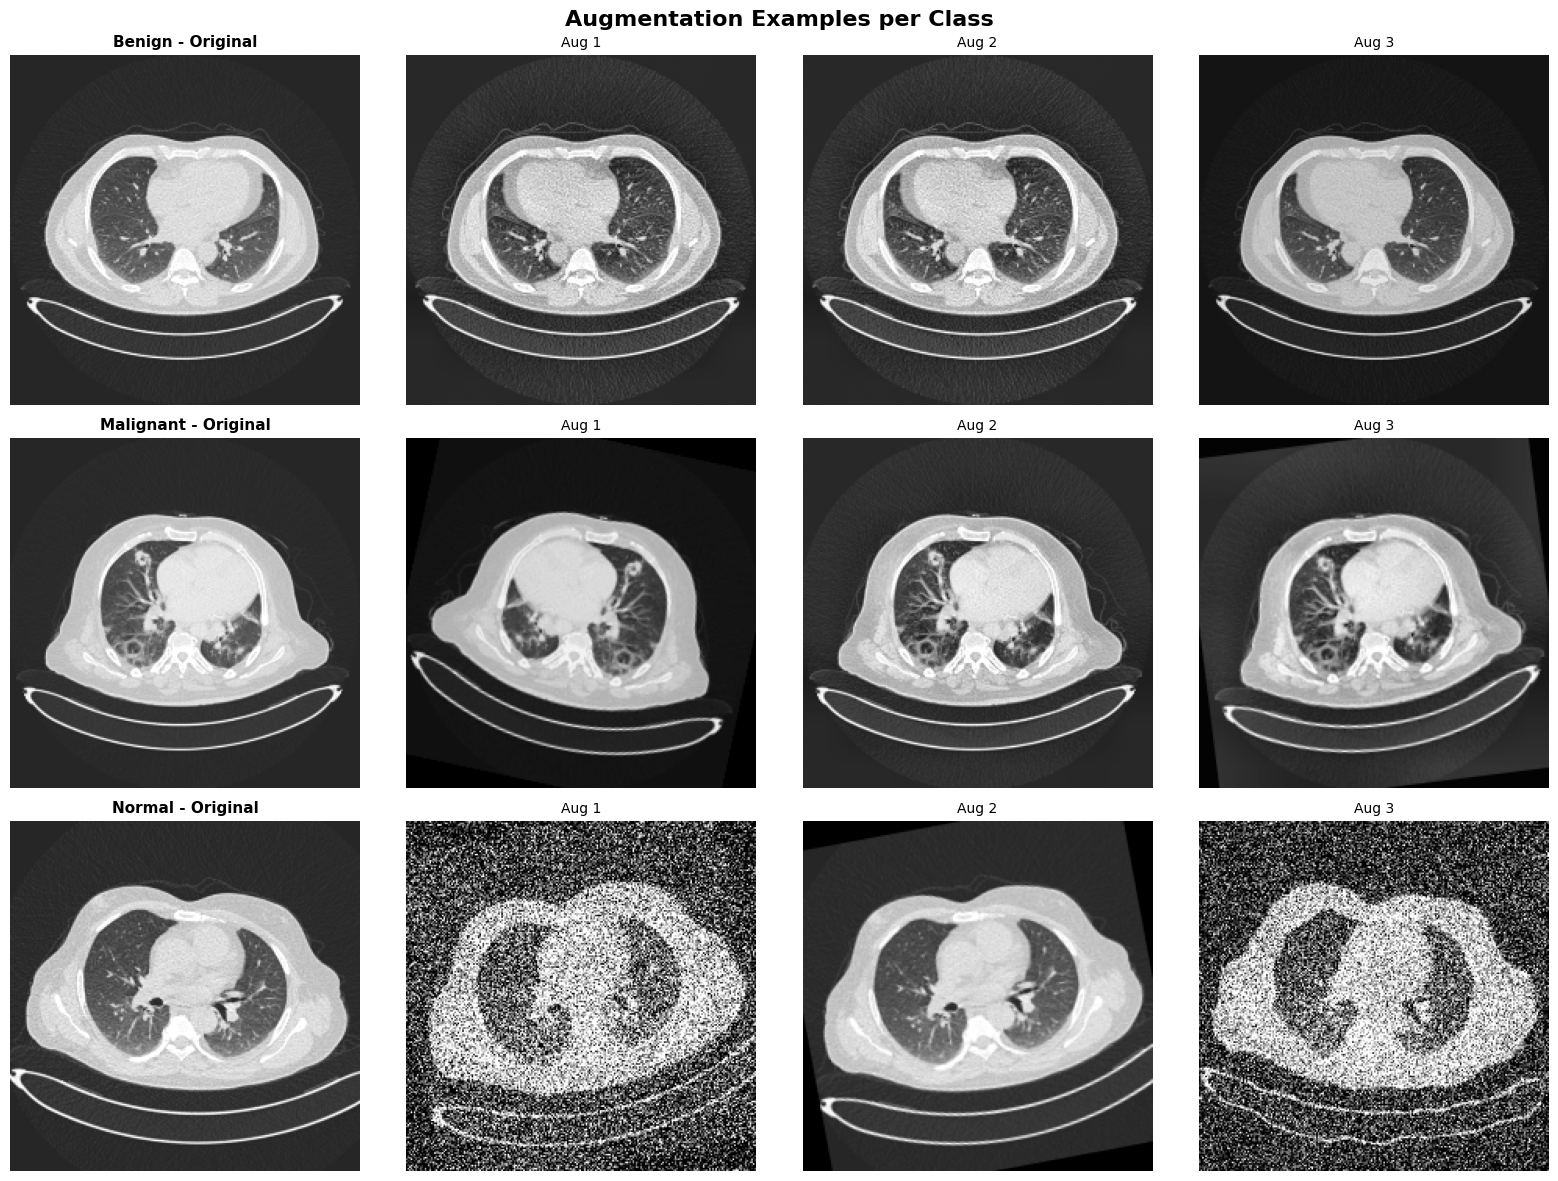


Detailed augmentation grid (9 variations)...


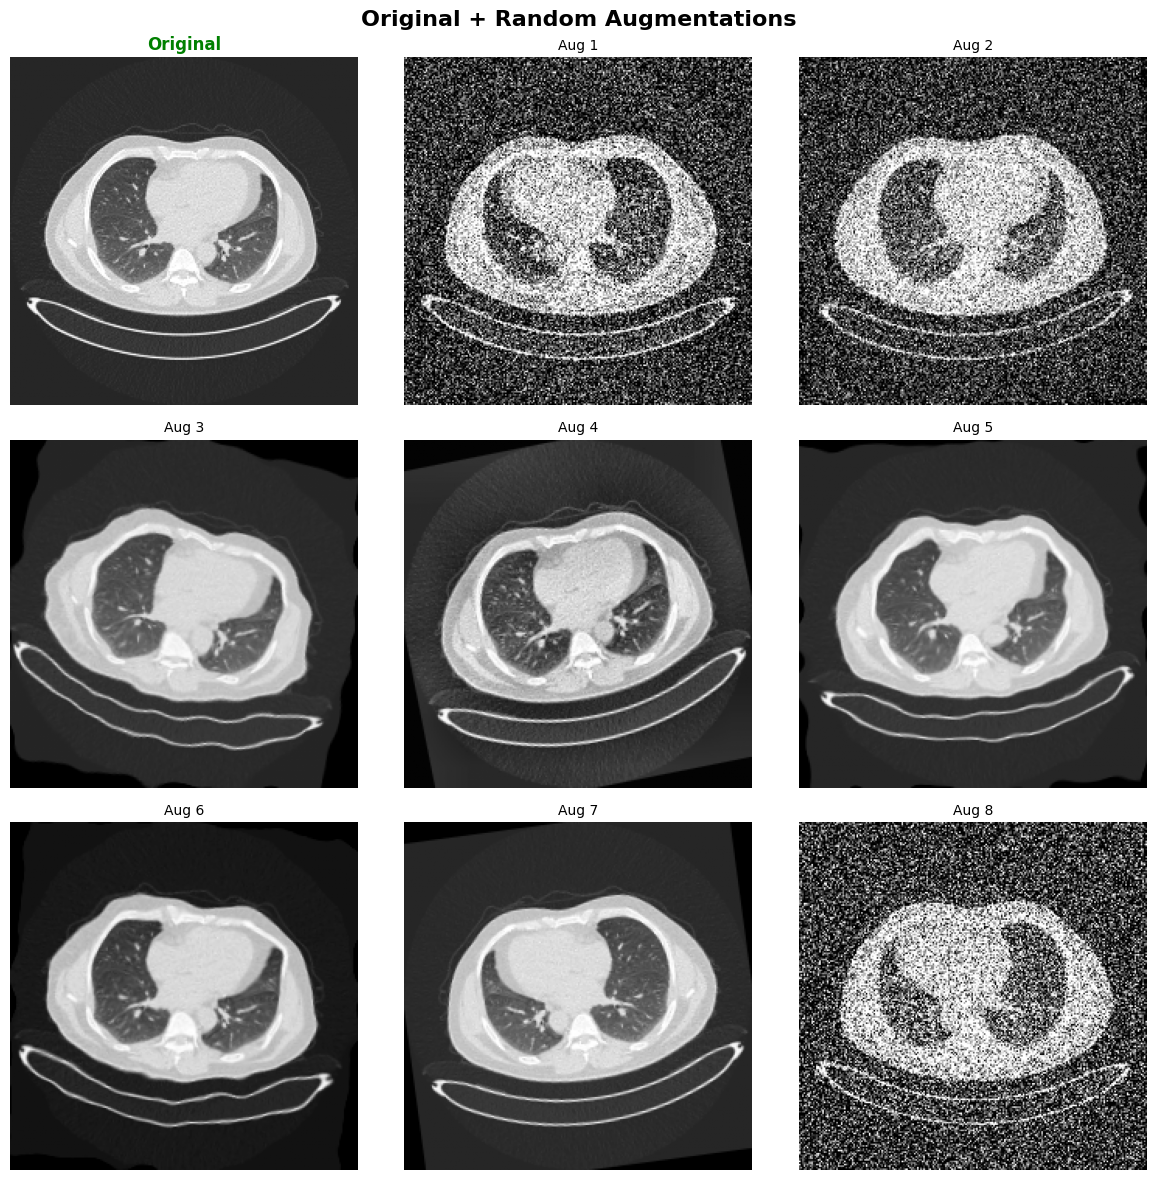


✅ BATCH VERIFICATION

Batch shape: torch.Size([64, 1, 224, 224])
Batch class distribution: {1: 22, 2: 23, 0: 19}
Pixel value range: [-1.00, 1.00]

🎉 READY TO TRAIN!

✅ Zero extra disk space used
✅ Every batch is class-balanced (WeightedRandomSampler)
✅ Every image is randomly augmented on-the-fly
✅ Class-weighted loss configured
✅ Augmentation visualizations displayed

💡 Use train_loader, val_loader, test_loader for training!
💡 Loss function: criterion = nn.CrossEntropyLoss(weight=class_weights.to('cuda'))


In [2]:
"""
═══════════════════════════════════════════════════════════════════════
 KAGGLE ONE-CELL: Augmentation + Visualization + DataLoader
 Dataset: IQ-OTH/NCCD Lung Cancer CT
═══════════════════════════════════════════════════════════════════════

 Complete pipeline in ONE CELL:
   1. Configurable Albumentations pipeline
   2. Visualization of augmentations
   3. Class-balanced DataLoaders (WeightedRandomSampler)
   4. Class-weighted loss

 Just run this cell and you're ready to train!
"""


SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {DEVICE}")


# ═══════════════════════════════════════════════════════════════════════
# CONFIG — TWEAK THESE!
# ═══════════════════════════════════════════════════════════════════════

class Config:
    # ── Dataset ──
    DATASET_ROOT = '/kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset'
    
    # IMPORTANT: Folder names in your dataset (note: "Bengin" is a typo in the original dataset)
    CLASSES = ["Bengin cases", "Malignant cases", "Normal cases"]
    CLASS_TO_IDX = {"Bengin cases": 0, "Malignant cases": 1, "Normal cases": 2}
    IDX_TO_CLASS = {0: "Benign", 1: "Malignant", 2: "Normal"}
    NUM_CLASSES = 3
    
    # ── Image ──
    IMG_SIZE = 224
    BATCH_SIZE = 64
    SEED = 42
    
    # ── Augmentation Parameters (TWEAK THESE!) ──
    # Geometric
    HFLIP_PROB = 0.5                 # Horizontal flip probability
    ROTATE_LIMIT = 15                # ±15° rotation range
    ROTATE_PROB = 0.5                # Rotation probability
    ELASTIC_ALPHA = 120              # Elastic deformation intensity
    ELASTIC_SIGMA = 6                # Elastic smoothness
    ELASTIC_PROB = 0.3               # Elastic transform probability
    
    # Photometric
    CLAHE_CLIP = 2.0                 # CLAHE contrast limit
    CLAHE_PROB = 0.3                 # CLAHE probability
    BRIGHTNESS_LIMIT = 0.1           # ±10% brightness
    CONTRAST_LIMIT = 0.1             # ±10% contrast
    BC_PROB = 0.3                    # Brightness/contrast probability
    NOISE_VAR = (10, 50)            # Gaussian noise variance range
    NOISE_PROB = 0.2                 # Noise probability

cfg = Config()


# ═══════════════════════════════════════════════════════════════════════
# AUGMENTATION PIPELINE
# ═══════════════════════════════════════════════════════════════════════

def get_train_transform(config=cfg):
    """Training augmentation - medical imaging pipeline."""
    return A.Compose([
        A.Resize(config.IMG_SIZE, config.IMG_SIZE),
        
        # Geometric
        A.HorizontalFlip(p=config.HFLIP_PROB),
        A.Rotate(limit=config.ROTATE_LIMIT, p=config.ROTATE_PROB, border_mode=0),
        A.ElasticTransform(
            alpha=config.ELASTIC_ALPHA,
            sigma=config.ELASTIC_SIGMA,
            p=config.ELASTIC_PROB,
            border_mode=0
        ),
        
        # Photometric
        A.CLAHE(
            clip_limit=config.CLAHE_CLIP,
            tile_grid_size=(8, 8),
            p=config.CLAHE_PROB
        ),
        A.RandomBrightnessContrast(
            brightness_limit=config.BRIGHTNESS_LIMIT,
            contrast_limit=config.CONTRAST_LIMIT,
            p=config.BC_PROB
        ),
        A.GaussNoise(var_limit=config.NOISE_VAR, p=config.NOISE_PROB),
    ])

def get_val_transform(config=cfg):
    """Validation/test - resize only."""
    return A.Compose([
        A.Resize(config.IMG_SIZE, config.IMG_SIZE),
    ])

train_transform = get_train_transform()
val_transform = get_val_transform()


# ═══════════════════════════════════════════════════════════════════════
# VISUALIZATION FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════

def visualize_augmentation_grid(image_path, num_augmentations=8):
    """
    Show original + N augmented versions in a 3x3 grid.
    Returns: matplotlib figure
    """
    # Load image
    if isinstance(image_path, str):
        img = Image.open(image_path).convert('L')
        img = np.array(img)
    else:
        img = image_path
    
    # Resize original (no augmentation)
    img_resized = val_transform(image=img)['image']
    
    # Generate augmented versions
    augmented_imgs = [img_resized]  # Original first
    for _ in range(num_augmentations):
        aug = train_transform(image=img)['image']
        augmented_imgs.append(aug)
    
    # Create grid
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle('Original + Random Augmentations', fontsize=16, y=0.98, weight='bold')
    
    for i, aug_img in enumerate(augmented_imgs):
        if i >= 9:
            break
        row = i // 3
        col = i % 3
        
        axes[row, col].imshow(aug_img, cmap='gray', vmin=0, vmax=255)
        if i == 0:
            axes[row, col].set_title('Original', fontsize=12, color='green', weight='bold')
        else:
            axes[row, col].set_title(f'Aug {i}', fontsize=10)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    return fig


def visualize_class_augmentations(image_paths):
    """
    Visualize one sample from each class + their augmentations.
    Args: image_paths - list of 3 image paths [benign, malignant, normal]
    """
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle('Augmentation Examples per Class', fontsize=16, weight='bold')
    
    class_names = ['Benign', 'Malignant', 'Normal']
    
    for row, (img_path, class_name) in enumerate(zip(image_paths, class_names)):
        # Load image
        img = Image.open(img_path).convert('L')
        img = np.array(img)
        img_resized = val_transform(image=img)['image']
        
        # Original
        axes[row, 0].imshow(img_resized, cmap='gray', vmin=0, vmax=255)
        axes[row, 0].set_title(f'{class_name} - Original', fontsize=11, weight='bold')
        axes[row, 0].axis('off')
        
        # 3 augmentations
        for col in range(1, 4):
            aug = train_transform(image=img)['image']
            axes[row, col].imshow(aug, cmap='gray', vmin=0, vmax=255)
            axes[row, col].set_title(f'Aug {col}', fontsize=10)
            axes[row, col].axis('off')
    
    plt.tight_layout()
    return fig


# ═══════════════════════════════════════════════════════════════════════
# DATASET CLASS
# ═══════════════════════════════════════════════════════════════════════

class CTDataset(Dataset):
    """
    CT scan dataset with online augmentation.
    Augmentation happens in __getitem__ — no extra disk space.
    """
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        img = Image.open(self.image_paths[idx]).convert('L')
        img = np.array(img)

        # Augment (online, in-memory)
        img = self.transform(image=img)['image']

        # Normalize to [-1, 1]
        img = img.astype(np.float32) / 255.0 * 2.0 - 1.0
        img = torch.FloatTensor(img).unsqueeze(0)  # (1, H, W)
        
        label = torch.LongTensor([self.labels[idx]]).squeeze()
        return img, label


# ═══════════════════════════════════════════════════════════════════════
# DATA LOADING & DATALOADER BUILDER
# ═══════════════════════════════════════════════════════════════════════

def load_paths(root_dir):
    """Load all image paths and labels."""
    paths, labels = [], []
    for class_name in cfg.CLASSES:
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"⚠️  WARNING: {class_dir} not found!")
            continue
        for f in sorted(os.listdir(class_dir)):
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                paths.append(os.path.join(class_dir, f))
                labels.append(cfg.CLASS_TO_IDX[class_name])
    return paths, labels


def build_dataloaders():
    """
    Build train/val/test DataLoaders with:
      - Stratified 70/15/15 split
      - WeightedRandomSampler for class balance
      - Online augmentation
      - Class-weighted loss
    """
    print("\n" + "="*60)
    print("📊 BUILDING DATALOADERS")
    print("="*60)
    
    # Load all paths
    all_paths, all_labels = load_paths(cfg.DATASET_ROOT)
    print(f"\nTotal images: {len(all_paths)}")
    print(f"Distribution: {dict(Counter(all_labels))}")
    
    # Convert to class names
    for idx in sorted(set(all_labels)):
        count = all_labels.count(idx)
        print(f"  {cfg.IDX_TO_CLASS[idx]}: {count} images")

    # Stratified split 70/15/15
    train_p, temp_p, train_l, temp_l = train_test_split(
        all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=cfg.SEED
    )
    val_p, test_p, val_l, test_l = train_test_split(
        temp_p, temp_l, test_size=0.50, stratify=temp_l, random_state=cfg.SEED
    )

    print(f"\n✂️  Split: Train={len(train_p)}, Val={len(val_p)}, Test={len(test_p)}")
    print(f"Train distribution: {dict(Counter(train_l))}")

    # ── WeightedRandomSampler for class balance ──
    counts = Counter(train_l)
    weight_per_class = {c: 1.0 / n for c, n in counts.items()}
    sample_weights = [weight_per_class[l] for l in train_l]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_l), replacement=True)

    # ── Class-weighted loss ──
    total = sum(counts.values())
    class_weights = torch.ones(cfg.NUM_CLASSES)
    for i in range(cfg.NUM_CLASSES):
        if i in counts and counts[i] > 0:
            class_weights[i] = total / (cfg.NUM_CLASSES * counts[i])
    
    present_classes = [cfg.IDX_TO_CLASS[i] for i in range(cfg.NUM_CLASSES) if i in counts]
    missing_classes = [cfg.IDX_TO_CLASS[i] for i in range(cfg.NUM_CLASSES) if i not in counts]
    
    print(f"\n✅ Classes present: {present_classes}")
    if missing_classes:
        print(f"⚠️  Classes MISSING: {missing_classes} (weight=1.0)")
    
    print(f"\n🎯 Class weights for loss:")
    for i in range(cfg.NUM_CLASSES):
        print(f"  {cfg.IDX_TO_CLASS[i]}: {class_weights[i]:.2f}× penalty")

    # ── Build datasets ──
    train_ds = CTDataset(train_p, train_l, train_transform)
    val_ds = CTDataset(val_p, val_l, val_transform)
    test_ds = CTDataset(test_p, test_l, val_transform)

    # ── Build loaders ──
    train_loader = DataLoader(
        train_ds, batch_size=cfg.BATCH_SIZE,
        sampler=sampler, num_workers=2, pin_memory=True, drop_last=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg.BATCH_SIZE,
        shuffle=False, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=cfg.BATCH_SIZE,
        shuffle=False, num_workers=2, pin_memory=True
    )

    return train_loader, val_loader, test_loader, class_weights, (train_p, train_l)


# ═══════════════════════════════════════════════════════════════════════
# MAIN EXECUTION — RUN EVERYTHING
# ═══════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("\n" + "╔" + "="*60 + "╗")
    print("║  AUGMENTATION + DATALOADER PIPELINE                      ║")
    print("╚" + "="*60 + "╝")
    
    # ── Step 1: Build DataLoaders ──
    train_loader, val_loader, test_loader, class_weights, (train_paths, train_labels) = build_dataloaders()
    
    # ── Step 2: Visualize Augmentations ──
    print("\n" + "="*60)
    print("🎨 VISUALIZING AUGMENTATIONS")
    print("="*60)
    
    # Get one sample per class for visualization
    sample_images = []
    for class_idx in sorted(set(train_labels)):
        class_paths = [p for p, l in zip(train_paths, train_labels) if l == class_idx]
        if len(class_paths) > 0:
            sample_images.append(class_paths[0])
    
    if len(sample_images) >= 3:
        print(f"\nCreating augmentation visualization for all 3 classes...")
        fig = visualize_class_augmentations(sample_images)
        plt.show()
    
    # Show detailed grid for first class
    if len(sample_images) > 0:
        print(f"\nDetailed augmentation grid (9 variations)...")
        fig = visualize_augmentation_grid(sample_images[0])
        plt.show()
    
    # ── Step 3: Verify Batch ──
    print("\n" + "="*60)
    print("✅ BATCH VERIFICATION")
    print("="*60)
    
    batch_imgs, batch_labels = next(iter(train_loader))
    print(f"\nBatch shape: {batch_imgs.shape}")
    print(f"Batch class distribution: {dict(Counter(batch_labels.numpy().tolist()))}")
    print(f"Pixel value range: [{batch_imgs.min():.2f}, {batch_imgs.max():.2f}]")
    
    # ── Step 4: Loss Function ──
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    
    # ── Summary ──
    print("\n" + "="*60)
    print("🎉 READY TO TRAIN!")
    print("="*60)
    print("\n✅ Zero extra disk space used")
    print("✅ Every batch is class-balanced (WeightedRandomSampler)")
    print("✅ Every image is randomly augmented on-the-fly")
    print("✅ Class-weighted loss configured")
    print("✅ Augmentation visualizations displayed")
    print("\n💡 Use train_loader, val_loader, test_loader for training!")
    print(f"💡 Loss function: criterion = nn.CrossEntropyLoss(weight=class_weights.to('{DEVICE}'))")


✅ CONFIG loaded
   Model : DepthWiseMamba-Pico
   Epochs: 50
   Optim : Adam  lr=5e-05
   Sched : None
   W&B   : ON
✅ DSMaT architecture defined
🏗️  DepthWiseMamba-Pico | Params: 837,116 (0.84M)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc



📐 GFLOPs ANALYSIS
  Forward  (inference):  0.0694 GFLOPs
  Backward (≈2× fwd):    0.1388 GFLOPs
  Fwd+Bwd  (1 step):     0.2082 GFLOPs
  Per epoch (0 batches): 0.00 GFLOPs
  Total training (50 ep):  0.00 GFLOPs
  Parameters:             0.84M
✅ Training utilities defined


✅ W&B run initialised

🚀 Starting training for DepthWiseMamba-Pico1...
  Ep   1/50 | Tr 1.2367/0.3452 | Val 1.2378/0.3818 | 3.8s ★ saved
  Ep   2/50 | Tr 1.1835/0.3864 | Val 1.1409/0.3818 | 3.4s
  Ep   3/50 | Tr 1.1251/0.4077 | Val 0.9532/0.6242 | 3.4s ★ saved
  Ep   4/50 | Tr 1.0710/0.4446 | Val 0.9296/0.6364 | 3.5s ★ saved
  Ep   5/50 | Tr 1.0571/0.4432 | Val 0.8680/0.6485 | 3.4s ★ saved
  Ep   6/50 | Tr 1.0925/0.4190 | Val 0.8443/0.6606 | 3.5s ★ saved
  Ep   7/50 | Tr 1.0681/0.4347 | Val 0.8887/0.5879 | 3.4s
  Ep   8/50 | Tr 1.0103/0.5000 | Val 0.8536/0.6303 | 3.3s
  Ep   9/50 | Tr 0.9985/0.4886 | Val 0.7954/0.7091 | 3.4s ★ saved
  Ep  10/50 | Tr 0.9802/0.5099 | Val 0.8147/0.6424 | 3.5s
  Ep  11/50 | Tr 0.9973/0.4986 | Val 0.8084/0.6485 | 3.4s
  Ep  12/50 | Tr 0.9563/0.5284 | Val 0.7912/0.6424 | 3.4s
  Ep  13/50 | Tr 0.9951/0.5256 | Val 0.7272/0.7212 | 3.5s ★ saved
  Ep  14/50 | Tr 0.9151/0.5682 | Val 0.7520/0.6606 | 3.3s
  Ep  15/50 | Tr 0.9185/0.5497 | Val 0.7717/0.6606 | 3.3s
  E

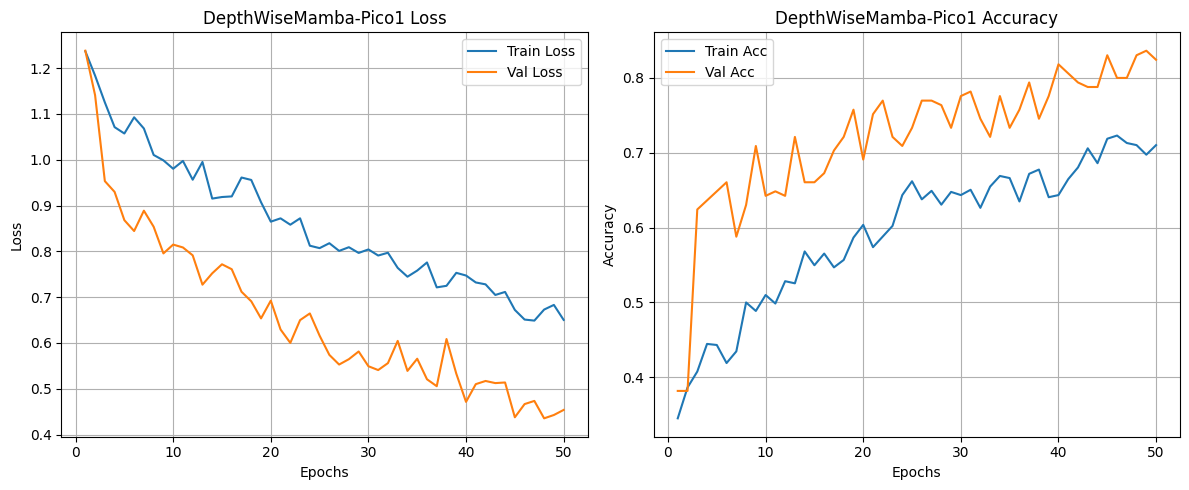

  TEST EVALUATION: DepthWiseMamba-Pico1 | Test Acc: 83.03%
                 precision    recall  f1-score   support

   Bengin cases       0.67      0.67      0.67        18
Malignant cases       0.85      0.89      0.87        85
   Normal cases       0.84      0.79      0.82        62

       accuracy                           0.83       165
      macro avg       0.79      0.78      0.79       165
   weighted avg       0.83      0.83      0.83       165



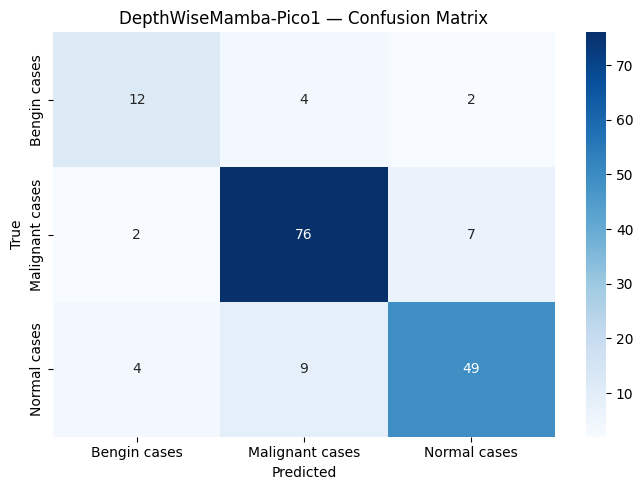

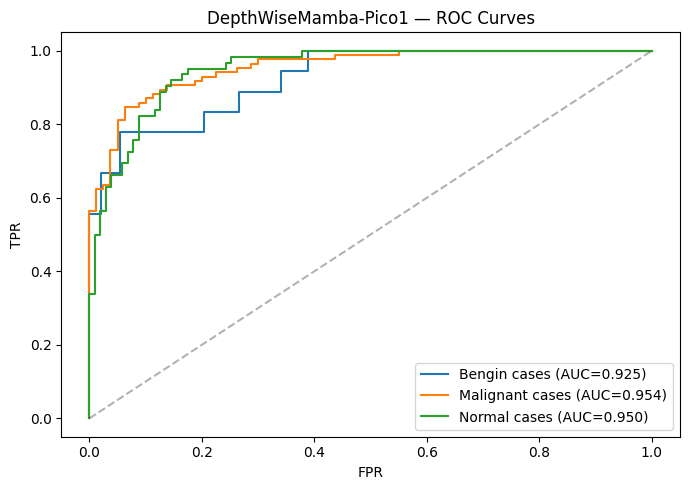

cumulative_gflops,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
forward_gflops,▁
fwd_bwd_gflops,▁
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
params_M,▁
per_epoch_gflops,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_acc,▁
test_f1_macro,▁
test_loss,▁
+5,...



✅ W&B run finished — config, metrics, and evaluation logged.

🏆 DepthWiseMamba-Pico1 | Test Acc: 83.03% | Saved: ./saved_models/DepthWiseMamba-Pico1_best.pth
✅ Done!


In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 2 — CONFIG + MODELS + TRAINING + EVALUATION                       ║
# ║  Everything is driven by the single CONFIG dict below.                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# 2.1  UNIFIED EXPERIMENT CONFIG
# ═══════════════════════════════════════════════════════════════════════════════
import wandb
CONFIG = {
    # ── Data ──────────────────────────────────────────────────────────────────
    "batch_size": cfg.BATCH_SIZE,
    "num_workers": 4,
    "num_classes": cfg.NUM_CLASSES,

    # ── Model Selection ──────────────────────────────────────────────────────
    #   Pick ONE: "DepthWiseMamba-Pico" | "DepthwiseMamba-Nano"
    "model_name": "DepthWiseMamba-Pico",

    # ── Model Architecture Hyperparameters ───────────────────────────────────
    "model": {
        "DepthWiseMamba-Pico": {
            "stem_channels":  (16, 32),
            "stage_channels": (48, 96, 128, 192),
            "stage_depths":   (1, 1, 2, 2),
            "sa_heads":       (4, 4),
            "mlp_expand":     2,
            "dropout":        0.4,
        },
        "DepthwiseMamba-Nano": {
            "stem_channels":  (24, 48),
            "stage_channels": (64, 128, 192, 256),
            "stage_depths":   (1, 2, 2, 2),
            "sa_heads":       (4, 4),
            "mlp_expand":     3,
            "dropout":        0.4,
        },
    },

    # ── Training ─────────────────────────────────────────────────────────────
    "epochs": 50,
    "optimizer": "Adam",           # "AdamW" | "Adam" | "SGD"
    "optimizer_params": {
        "lr":           5e-5,
        "weight_decay": 1e-3,
    },
    "scheduler": None,   # "CosineAnnealingLR" | "StepLR" | "ReduceLROnPlateau" | None
    "scheduler_params": {},              # extra kwargs forwarded to the scheduler
    "grad_clip_max_norm": 1.0,

    # ── GFLOPs Tracking ──────────────────────────────────────────────────────
    "track_flops": True,             # Set False to skip FLOP counting entirely

    # ── W&B ──────────────────────────────────────────────────────────────────
    "wandb_project": "DSMaT-LungCancer",
    "wandb_enabled": True,
}

print("✅ CONFIG loaded")
print(f"   Model : {CONFIG['model_name']}")
print(f"   Epochs: {CONFIG['epochs']}")
print(f"   Optim : {CONFIG['optimizer']}  lr={CONFIG['optimizer_params']['lr']}")
print(f"   Sched : {CONFIG['scheduler']}")
print(f"   W&B   : {'ON' if CONFIG['wandb_enabled'] else 'OFF'}")



# ═══════════════════════════════════════════════════════════════════════════════
# 2.3  MODEL ARCHITECTURE
# ═══════════════════════════════════════════════════════════════════════════════

# ── Building Blocks ──────────────────────────────────────────────────────────

class DSConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size, stride, padding, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=bias)
    def forward(self, x):
        return self.pw(self.dw(x))

class DSConvStem(nn.Module):
    def __init__(self, in_ch=1, mid_ch=32, out_ch=64):
        super().__init__()
        self.stem = nn.Sequential(
            DSConv2d(in_ch, mid_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(mid_ch), nn.GELU(),
            DSConv2d(mid_ch, out_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_ch), nn.GELU(),
        )
    def forward(self, x):
        return self.stem(x)

class DSConvResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            DSConv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels), nn.GELU(),
            DSConv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
        )
    def forward(self, x):
        return self.block(x) + x

class DSConvDownsample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.down = nn.Sequential(
            DSConv2d(in_ch, out_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_ch),
        )
    def forward(self, x):
        return self.down(x)

# ── Mamba / Attention / MLP ──────────────────────────────────────────────────

class SelectiveScan(nn.Module):
    def __init__(self, d_inner, d_state=16):
        super().__init__()
        self.d_state = d_state
        self.dt_rank = max(1, d_inner // 16)
        self.x_proj  = nn.Linear(d_inner, self.dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, d_inner, bias=True)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0).expand(d_inner, -1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D     = nn.Parameter(torch.ones(d_inner))

    def forward(self, x):
        B_batch, D, L = x.shape
        x_seq = x.transpose(1, 2)
        x_dbl = self.x_proj(x_seq)
        dt_raw, B_param, C_param = x_dbl.split(
            [self.dt_rank, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt_raw))
        A  = -torch.exp(self.A_log)
        dA  = torch.exp(dt.unsqueeze(-1) * A)
        dBx = dt.unsqueeze(-1) * B_param.unsqueeze(2)
        h = torch.zeros(B_batch, D, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for t in range(L):
            h = dA[:, t] * h + dBx[:, t] * x_seq[:, t, :, None]
            yt = (h * C_param[:, t, None, :]).sum(-1)
            ys.append(yt)
        y = torch.stack(ys, dim=2)
        return y + self.D.unsqueeze(0).unsqueeze(-1) * x

class MambaVisionMixer(nn.Module):
    def __init__(self, dim, d_state=16, kernel_size=3):
        super().__init__()
        half = dim // 2
        self.proj_x   = nn.Linear(dim, half, bias=False)
        self.conv1d_x = nn.Conv1d(half, half, kernel_size, padding='same', groups=half)
        self.ssm      = SelectiveScan(half, d_state)
        self.proj_z   = nn.Linear(dim, half, bias=False)
        self.conv1d_z = nn.Conv1d(half, half, kernel_size, padding='same', groups=half)
        self.out_proj = nn.Linear(dim, dim)
        self.norm     = nn.LayerNorm(dim)

    def forward(self, x):
        residual = x
        x = self.norm(x)
        x1 = self.proj_x(x).transpose(1, 2)
        x1 = F.silu(self.conv1d_x(x1))
        x1 = self.ssm(x1)
        x2 = self.proj_z(x).transpose(1, 2)
        x2 = F.silu(self.conv1d_z(x2))
        out = torch.cat([x1, x2], dim=1).transpose(1, 2)
        return self.out_proj(out) + residual

class SelfAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
    def forward(self, x):
        normed = self.norm(x)
        out, _ = self.attn(normed, normed, normed)
        return out + x

class MLPBlock(nn.Module):
    def __init__(self, dim, expand=4, dropout=0.1):
        super().__init__()
        hidden = dim * expand
        self.net = nn.Sequential(
            nn.LayerNorm(dim), nn.Linear(dim, hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x) + x

class MambaVisionLayer(nn.Module):
    def __init__(self, dim, mixer_type='mamba', num_heads=4,
                 d_state=16, mlp_expand=4, dropout=0.1):
        super().__init__()
        if mixer_type == 'mamba':
            self.mixer = MambaVisionMixer(dim, d_state=d_state)
        else:
            self.mixer = SelfAttentionBlock(dim, num_heads=num_heads, dropout=dropout)
        self.mlp = MLPBlock(dim, expand=mlp_expand, dropout=dropout)
    def forward(self, x):
        return self.mlp(self.mixer(x))

# ── DSMaT Full Model ─────────────────────────────────────────────────────────

class DSMaT(nn.Module):
    def __init__(self, in_channels=1, stem_channels=(32, 64), stage_channels=(96, 192, 256, 384),
                 stage_depths=(2, 2, 4, 4), sa_heads=(4, 8), d_state=16,
                 mlp_expand=4, num_classes=3, dropout=0.2):
        super().__init__()
        stem_mid, stem_out = stem_channels
        self.stem = DSConvStem(in_channels, stem_mid, stem_out)

        self.down1  = DSConvDownsample(stem_out, stage_channels[0])
        self.stage1 = nn.Sequential(*[DSConvResBlock(stage_channels[0])
                                      for _ in range(stage_depths[0])])

        self.down2  = DSConvDownsample(stage_channels[0], stage_channels[1])
        self.stage2 = nn.Sequential(*[DSConvResBlock(stage_channels[1])
                                      for _ in range(stage_depths[1])])

        self.down3 = DSConvDownsample(stage_channels[1], stage_channels[2])
        n3 = stage_depths[2]; n3m = n3 // 2; n3a = n3 - n3m
        s3 = []
        for _ in range(n3m):
            s3.append(MambaVisionLayer(stage_channels[2], 'mamba',
                      d_state=d_state, mlp_expand=mlp_expand, dropout=dropout))
        for _ in range(n3a):
            s3.append(MambaVisionLayer(stage_channels[2], 'attention',
                      num_heads=sa_heads[0], mlp_expand=mlp_expand, dropout=dropout))
        self.stage3 = nn.ModuleList(s3)

        self.down4 = DSConvDownsample(stage_channels[2], stage_channels[3])
        n4 = stage_depths[3]; n4m = n4 // 2; n4a = n4 - n4m
        s4 = []
        for _ in range(n4m):
            s4.append(MambaVisionLayer(stage_channels[3], 'mamba',
                      d_state=d_state, mlp_expand=mlp_expand, dropout=dropout))
        for _ in range(n4a):
            s4.append(MambaVisionLayer(stage_channels[3], 'attention',
                      num_heads=sa_heads[1], mlp_expand=mlp_expand, dropout=dropout))
        self.stage4 = nn.ModuleList(s4)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.LayerNorm(stage_channels[3]),
            nn.Dropout(dropout),
            nn.Linear(stage_channels[3], num_classes),
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.stem(x)
        x = self.down1(x); x = self.stage1(x)
        x = self.down2(x); x = self.stage2(x)
        x = self.down3(x)
        B3, C3, H3, W3 = x.shape
        x = x.flatten(2).transpose(1, 2)
        for layer in self.stage3:
            x = layer(x)
        x = x.transpose(1, 2).reshape(B, C3, H3, W3)
        x = self.down4(x)
        B4, C4, H4, W4 = x.shape
        x = x.flatten(2).transpose(1, 2)
        for layer in self.stage4:
            x = layer(x)
        x = x.transpose(1, 2).reshape(B, C4, H4, W4)
        x = self.pool(x).flatten(1)
        return self.head(x)

print("✅ DSMaT architecture defined")

# ── Build model from CONFIG ──────────────────────────────────────────────────

def build_model(config):
    """Instantiate the selected model variant from CONFIG."""
    name = config["model_name"]
    arch = config["model"][name]
    model = DSMaT(num_classes=config["num_classes"], **arch).to(DEVICE)
    return model

model = build_model(CONFIG)
n_params = sum(p.numel() for p in model.parameters())
print(f"🏗️  {CONFIG['model_name']} | Params: {n_params:,} ({n_params/1e6:.2f}M)")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.3.1  GFLOPs COMPUTATION
# ═══════════════════════════════════════════════════════════════════════════════

def compute_gflops(model, input_size=(1, 3, 224, 224), device=DEVICE, verbose=True):
    """
    Compute GFLOPs for a model using torch.profiler.

    Returns dict with:
      - forward_gflops:   GFLOPs for a single forward pass (inference)
      - backward_gflops:  Estimated GFLOPs for backward pass (≈ 2× forward)
      - fwd_bwd_gflops:   Total for one forward + backward step (≈ 3× forward)
      - per_epoch_gflops:  FLOPs per epoch = fwd_bwd × num_batches
      - total_gflops:      FLOPs for full training = per_epoch × epochs

    Args:
        model: nn.Module
        input_size: (batch, channels, height, width)
        device: torch.device
        verbose: Print results

    Usage:
        flops_info = compute_gflops(model)
        # Access: flops_info['forward_gflops'], flops_info['total_gflops'], etc.
    """
    model.eval()
    dummy = torch.randn(*input_size, device=device)

    # Count forward FLOPs using torch.profiler
    with torch.profiler.profile(
        activities=[torch.profiler.ProfilerActivity.CPU]
        + ([torch.profiler.ProfilerActivity.CUDA] if device.type == 'cuda' else []),
        record_shapes=True,
        with_flops=True,
    ) as prof:
        with torch.no_grad():
            _ = model(dummy)

    # Sum all FLOPs from profiler events
    total_flops = 0
    for event in prof.key_averages():
        if event.flops is not None and event.flops > 0:
            total_flops += event.flops

    forward_gflops = total_flops / 1e9
    backward_gflops = forward_gflops * 2.0      # Standard approximation: backward ≈ 2× forward
    fwd_bwd_gflops = forward_gflops + backward_gflops  # Single training step ≈ 3× forward

    # Per-epoch and total training estimates
    batch_size = input_size[0]
    num_train_samples = len(train_loader.dataset) if 'train_loader' in dir() else 0
    num_batches = len(train_loader) if 'train_loader' in dir() else 0
    epochs = CONFIG.get('epochs', 1)

    # Scale by actual batch size
    actual_batch = CONFIG.get('batch_size', batch_size)
    scale = actual_batch / batch_size  # Profiled with batch=1, scale to real batch

    per_epoch_gflops = fwd_bwd_gflops * scale * num_batches
    total_gflops = per_epoch_gflops * epochs

    info = {
        'forward_gflops':     round(forward_gflops, 4),
        'backward_gflops':    round(backward_gflops, 4),
        'fwd_bwd_gflops':     round(fwd_bwd_gflops, 4),
        'per_epoch_gflops':   round(per_epoch_gflops, 2),
        'total_gflops':       round(total_gflops, 2),
        'params_M':           round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
    }

    if verbose:
        print("\n" + "="*60)
        print("📐 GFLOPs ANALYSIS")
        print("="*60)
        print(f"  Forward  (inference):  {info['forward_gflops']:.4f} GFLOPs")
        print(f"  Backward (≈2× fwd):    {info['backward_gflops']:.4f} GFLOPs")
        print(f"  Fwd+Bwd  (1 step):     {info['fwd_bwd_gflops']:.4f} GFLOPs")
        print(f"  Per epoch ({num_batches} batches): {info['per_epoch_gflops']:.2f} GFLOPs")
        print(f"  Total training ({epochs} ep):  {info['total_gflops']:.2f} GFLOPs")
        print(f"  Parameters:             {info['params_M']:.2f}M")
        print("="*60)

    model.train()
    return info

# ── Compute & log GFLOPs if enabled ──────────────────────────────────────────
flops_info = None
if CONFIG.get('track_flops', False):
    flops_info = compute_gflops(model, input_size=(1, 1, cfg.IMG_SIZE, cfg.IMG_SIZE))
else:
    print("ℹ️  GFLOPs tracking disabled (set CONFIG['track_flops'] = True to enable)")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.4  TRAINING & EVALUATION UTILITIES
# ═══════════════════════════════════════════════════════════════════════════════

def _build_optimizer(model, config):
    """Build an optimizer from CONFIG."""
    name   = config["optimizer"]
    params = config["optimizer_params"]
    if name == "AdamW":
        return optim.AdamW(model.parameters(), **params)
    elif name == "Adam":
        return optim.Adam(model.parameters(), **params)
    elif name == "SGD":
        return optim.SGD(model.parameters(), momentum=params.get("momentum", 0.9),
                         lr=params["lr"], weight_decay=params.get("weight_decay", 0))
    else:
        raise ValueError(f"Unknown optimizer: {name}")

def _build_scheduler(optimizer, config):
    """Build a LR scheduler from CONFIG (returns None if disabled)."""
    name = config["scheduler"]
    if name is None or name == "None":
        return None
    extra = config.get("scheduler_params", {})
    if name == "CosineAnnealingLR":
        return optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config["epochs"], **extra)
    elif name == "StepLR":
        return optim.lr_scheduler.StepLR(
            optimizer, step_size=extra.get("step_size", 10),
            gamma=extra.get("gamma", 0.1))
    elif name == "ReduceLROnPlateau":
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=extra.get("patience", 5),
            factor=extra.get("factor", 0.5))
    else:
        raise ValueError(f"Unknown scheduler: {name}")

def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip, scaler):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Scale loss, backprop, unscale for gradient clipping, step optimizer, update scaler
        scaler.scale(loss).backward()

        # Unscale before clipping
        scaler.unscale_(optimizer)
        if grad_clip is not None and grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * labels.size(0)
        correct  += (outputs.argmax(1) == labels).sum().item()
        total    += labels.size(0)

    return loss_sum / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * labels.size(0)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (loss_sum / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

def plot_history(history, model_name="Model"):
    if not history or not history.get('train_loss'):
        print("⚠️ No history data to plot."); return
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
    ax1.plot(epochs_range, history['val_loss'],   label='Val Loss')
    ax1.set(title=f'{model_name} Loss', xlabel='Epochs', ylabel='Loss')
    ax1.legend(); ax1.grid(True)
    ax2.plot(epochs_range, history['train_acc'], label='Train Acc')
    ax2.plot(epochs_range, history['val_acc'],   label='Val Acc')
    ax2.set(title=f'{model_name} Accuracy', xlabel='Epochs', ylabel='Accuracy')
    ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()
    return fig

print("✅ Training utilities defined")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.5  W&B INIT + TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════

# ── Initialise W&B ───────────────────────────────────────────────────────────
if CONFIG["wandb_enabled"]:
    from kaggle_secrets import UserSecretsClient
    wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))
    wandb.init(
        project=CONFIG["wandb_project"],
        name=CONFIG["model_name"],
        config=CONFIG,
    )
    print("✅ W&B run initialised")

# ── Training ─────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = _build_optimizer(model, CONFIG)
scheduler = _build_scheduler(optimizer, CONFIG)

history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
model_name   = CONFIG["model_name"] + "1"
save_path    = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
# Mixed precision scaler
scaler = GradScaler()

# ── Check for existing checkpoint ────────────────────────────────────────────
FORCE_RETRAIN = False   # flip to True to retrain from scratch

if os.path.exists(save_path) and not FORCE_RETRAIN:
    print(f"\n✅ Found existing model: {save_path}")
    checkpoint = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    scaler_state = checkpoint.get('scaler_state_dict', None)
    if scaler_state is not None:
        scaler.load_state_dict(scaler_state)
    history      = checkpoint.get('history', {})
    best_val_acc = checkpoint.get('val_acc', 0.0)
    best_epoch   = checkpoint.get('epoch', '?')
    print(f"   Loaded! Best Val Acc: {best_val_acc*100:.2f}% (Epoch {best_epoch})")
    plot_history(history, model_name)
else:
    print(f"\n🚀 Starting training for {model_name}...")
    for epoch in range(CONFIG["epochs"]):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE,
            CONFIG["grad_clip_max_norm"],scaler)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        # Scheduler step
        if scheduler is not None:
            if CONFIG["scheduler"] == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # ── W&B per-epoch logging ────────────────────────────────────────────
        if CONFIG["wandb_enabled"]:
            log_dict = {
                "epoch":      epoch + 1,
                "train_loss": tr_loss,
                "train_acc":  tr_acc,
                "val_loss":   val_loss,
                "val_acc":    val_acc,
                "lr":         optimizer.param_groups[0]['lr'],
            }
            # Track cumulative GFLOPs if enabled
            if flops_info is not None:
                cumulative_gflops = flops_info['per_epoch_gflops'] * (epoch + 1)
                log_dict["cumulative_gflops"] = round(cumulative_gflops, 2)
                log_dict["per_epoch_gflops"]  = flops_info['per_epoch_gflops']
            wandb.log(log_dict)

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch':                epoch + 1,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'val_acc':              val_acc,
                'val_loss':             val_loss,
                'model_name':           model_name,
                'history':              history,
            }, save_path)
            marker = ' ★ saved'
        else:
            marker = ''

        print(f"  Ep {epoch+1:3d}/{CONFIG['epochs']} | "
              f"Tr {tr_loss:.4f}/{tr_acc:.4f} | "
              f"Val {val_loss:.4f}/{val_acc:.4f} | "
              f"{time.time()-t0:.1f}s{marker}")

    # Reload best
    checkpoint = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n  💾 Best model loaded: Epoch {checkpoint['epoch']} | "
          f"Val Acc: {checkpoint['val_acc']*100:.2f}%")
    plot_history(history, model_name)

# ═══════════════════════════════════════════════════════════════════════════════
# 2.6  TEST-SET EVALUATION + W&B FINAL METRICS
# ═══════════════════════════════════════════════════════════════════════════════

test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE)

print("=" * 70)
print(f"  TEST EVALUATION: {model_name} | Test Acc: {test_acc*100:.2f}%")
print("=" * 70)

class_labels = cfg.CLASSES
report_str = classification_report(test_labels, test_preds, target_names=class_labels)
print(report_str)

# ── Confusion Matrix ─────────────────────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax_cm)
ax_cm.set_title(f'{model_name} — Confusion Matrix')
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
plt.tight_layout()
plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ROC Curves ───────────────────────────────────────────────────────────────
fig_roc, ax_roc = plt.subplots(figsize=(7, 5))
y_bin = label_binarize(test_labels, classes=[0, 1, 2])
for cls_i in range(CONFIG['num_classes']):
    fpr, tpr, _ = roc_curve(y_bin[:, cls_i], test_probs[:, cls_i])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f'{class_labels[cls_i]} (AUC={roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax_roc.set(title=f'{model_name} — ROC Curves', xlabel='FPR', ylabel='TPR')
ax_roc.legend()
plt.tight_layout()
plt.savefig(f'roc_curves_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class metrics ────────────────────────────────────────────────────────
per_class_acc  = [accuracy_score(test_labels[test_labels == c], test_preds[test_labels == c])
                  for c in range(CONFIG['num_classes'])]
per_class_prec = precision_score(test_labels, test_preds, average=None)
per_class_rec  = recall_score(test_labels, test_preds, average=None)
per_class_f1   = f1_score(test_labels, test_preds, average=None)

# ── W&B final logging ────────────────────────────────────────────────────────
if CONFIG["wandb_enabled"]:
    # Final scalar metrics
    final_log = {
        "test_loss": test_loss,
        "test_acc":  test_acc,
        "test_f1_macro": f1_score(test_labels, test_preds, average='macro'),
    }
    # Log GFLOPs summary if tracked
    if flops_info is not None:
        final_log.update({
            "forward_gflops":    flops_info['forward_gflops'],
            "fwd_bwd_gflops":    flops_info['fwd_bwd_gflops'],
            "total_train_gflops": flops_info['total_gflops'],
            "params_M":          flops_info['params_M'],
        })
    wandb.log(final_log)

    # Confusion matrix image
    wandb.log({"confusion_matrix": wandb.Image(fig_cm)})

    # ROC curves image
    wandb.log({"roc_curves": wandb.Image(fig_roc)})

    # Per-class metrics table
    metrics_table = wandb.Table(
        columns=["Class", "Accuracy", "Precision", "Recall", "F1"],
        data=[[class_labels[c], per_class_acc[c], per_class_prec[c],
               per_class_rec[c], per_class_f1[c]]
              for c in range(CONFIG['num_classes'])]
    )
    wandb.log({"per_class_metrics": metrics_table})

    wandb.finish()
    print("\n✅ W&B run finished — config, metrics, and evaluation logged.")

print(f"\n🏆 {model_name} | Test Acc: {test_acc*100:.2f}% | Saved: {save_path}")
print("✅ Done!")